# Лабораторна робота № 2

## Оптимізаційна задача та аналіз чутливості

**Дисципліна:** Інтелектуальний аналіз та візуалізація даних (СК26)
**Тривалість:** 2 год аудиторно + 3 год самостійної роботи · **Максимальна оцінка:** 4 бали

---

### Мета роботи

Побудувати оптимізаційну модель у двох середовищах, прочитати звіт про стійкість
і **ухвалити на його основі господарське рішення**.

Розв'язати задачу — не мета. Solver зробить це за дві секунди. Робота оцінюється за
те, що ви зумієте зі звіту витягнути.

### Дві частини

| Частина | Задача | Де виконується |
|---|---|---|
| **1** | виробнича задача — Excel і Python | аудиторно |
| **2** | транспортна задача — Python | самостійно |

Друга частина потрібна не для повторення. Там та сама методика поводиться інакше,
і ви маєте побачити, де саме проходить межа її застосовності.

### Що здається

1. Цей файл `.ipynb` із заповненими розв'язками. **Виконується згори донизу на чистому
   ядрі** (Kernel → Restart & Run All) без помилок — перевіряється першою дією на захисті.
2. Файл Excel з моделлю, налаштуваннями Solver і **звітом про стійкість** окремим аркушем.
3. Заповнена декларація про використання ШІ (етап 12).

### Оцінювання

| Бали | Що досягнуто |
|---|---|
| 0 | Модель не сформульовано або розв'язок не отримано |
| 1 | Розв'язок отримано лише в одному середовищі, звіт про стійкість не проаналізовано |
| 2 | Задачу розв'язано в обох середовищах і звіти зіставлено, але тіньові ціни та діапазони не інтерпретовано |
| 4 | Звіт прочитано й перевірено експериментом, ухвалено обґрунтоване рішення про закупівлю, виконано частину 2 з поясненням розбіжності |

---
## Крок 0. Ваші дані та варіант

In [2]:
ПІБ = 'Токарик Сергій Богданович'        # напр. 'Шевченко Тарас'
ГРУПА = 'ШІ-33'      # напр. 'КН-31'
ВАРІАНТ = 7     # ваш номер за списком групи

assert ПІБ and ГРУПА and 1 <= ВАРІАНТ <= 30, 'Заповніть ПІБ, ГРУПУ та ВАРІАНТ (1..30)'

In [3]:
# --- клітинку не редагувати: вона видає дані вашого варіанта -----------------
import json, numpy as np, pandas as pd

ДАНІ_ВАРІАНТІВ = json.loads('''{"1": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[0, 2, 1, 1], [3, 3, 0, 6], [2, 3, 0, 2], [4, 6, 0, 5], [3, 1, 5, 4]], "c": [21, 69, 44, 39], "b": [929, 410, 507, 865, 425], "ресурс_пропозиції": 1, "ціна_пропозиції": 16.2, "обсяг_пропозиції": 44}, "2": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[4, 2, 5, 2], [6, 5, 4, 2], [5, 2, 0, 3], [2, 1, 5, 0], [5, 5, 6, 2]], "c": [40, 66, 24, 34], "b": [1271, 702, 915, 1388, 804], "ресурс_пропозиції": 1, "ціна_пропозиції": 16.7, "обсяг_пропозиції": 204}, "3": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[5, 2, 6, 6], [3, 4, 3, 6], [1, 6, 6, 0], [3, 1, 6, 1], [4, 1, 1, 4]], "c": [51, 16, 34, 22], "b": [1189, 686, 1311, 512, 1030], "ресурс_пропозиції": 3, "ціна_пропозиції": 11.3, "обсяг_пропозиції": 348}, "4": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[5, 0, 0, 0], [1, 0, 5, 2], [2, 4, 6, 5], [3, 0, 5, 3], [2, 1, 2, 5]], "c": [41, 50, 54, 26], "b": [815, 344, 840, 840, 382], "ресурс_пропозиції": 4, "ціна_пропозиції": 8.3, "обсяг_пропозиції": 144}, "5": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[3, 0, 6, 6], [3, 2, 2, 4], [5, 5, 0, 6], [2, 1, 5, 3], [5, 5, 4, 2]], "c": [32, 66, 25, 24], "b": [874, 1034, 1349, 845, 1394], "ресурс_пропозиції": 2, "ціна_пропозиції": 8.6, "обсяг_пропозиції": 90}, "6": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[3, 2, 1, 4], [4, 2, 2, 1], [3, 5, 1, 2], [3, 2, 0, 2], [6, 4, 6, 3]], "c": [40, 62, 19, 57], "b": [630, 391, 1349, 811, 1085], "ресурс_пропозиції": 1, "ціна_пропозиції": 29.5, "обсяг_пропозиції": 268}, "7": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[0, 0, 5, 5], [4, 4, 0, 1], [2, 4, 0, 6], [6, 3, 4, 1], [2, 2, 1, 0]], "c": [20, 59, 63, 41], "b": [1189, 1189, 1217, 915, 424], "ресурс_пропозиції": 3, "ціна_пропозиції": 8.0, "обсяг_пропозиції": 314}, "8": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[2, 1, 3, 5], [3, 1, 0, 6], [1, 6, 1, 5], [2, 2, 4, 0], [6, 1, 2, 2]], "c": [60, 25, 59, 25], "b": [1279, 761, 376, 1230, 1065], "ресурс_пропозиції": 3, "ціна_пропозиції": 9.5, "обсяг_пропозиції": 234}, "9": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[5, 2, 1, 2], [5, 0, 1, 3], [5, 4, 6, 4], [4, 1, 1, 5], [6, 0, 3, 0]], "c": [58, 39, 54, 16], "b": [1147, 1199, 1280, 404, 1170], "ресурс_пропозиції": 2, "ціна_пропозиції": 6.1, "обсяг_пропозиції": 672}, "10": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[4, 0, 4, 3], [0, 6, 0, 6], [5, 5, 3, 5], [6, 2, 3, 3], [3, 0, 0, 4]], "c": [20, 29, 37, 63], "b": [905, 344, 866, 1390, 355], "ресурс_пропозиції": 0, "ціна_пропозиції": 5.3, "обсяг_пропозиції": 78}, "11": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[2, 1, 0, 3], [3, 1, 4, 0], [1, 0, 3, 2], [3, 2, 2, 6], [3, 6, 0, 3]], "c": [30, 16, 51, 35], "b": [1312, 838, 1062, 1038, 1236], "ресурс_пропозиції": 1, "ціна_пропозиції": 15.6, "обсяг_пропозиції": 778}, "12": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[5, 2, 0, 5], [1, 1, 3, 6], [6, 3, 5, 4], [2, 4, 6, 0], [4, 6, 2, 4]], "c": [39, 55, 36, 26], "b": [788, 661, 458, 1005, 535], "ресурс_пропозиції": 4, "ціна_пропозиції": 5.0, "обсяг_пропозиції": 762}, "13": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[1, 5, 3, 0], [6, 4, 6, 3], [4, 4, 4, 1], [0, 3, 5, 3], [3, 5, 3, 3]], "c": [59, 42, 53, 19], "b": [937, 1390, 603, 1120, 1334], "ресурс_пропозиції": 2, "ціна_пропозиції": 15.1, "обсяг_пропозиції": 646}, "14": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[4, 3, 3, 4], [6, 6, 1, 6], [1, 3, 5, 1], [1, 5, 1, 4], [4, 4, 0, 3]], "c": [26, 56, 41, 40], "b": [969, 672, 1364, 878, 618], "ресурс_пропозиції": 2, "ціна_пропозиції": 5.0, "обсяг_пропозиції": 222}, "15": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[5, 3, 3, 1], [2, 5, 6, 6], [3, 1, 0, 0], [0, 4, 4, 6], [2, 2, 2, 6]], "c": [64, 58, 34, 63], "b": [613, 316, 1035, 739, 810], "ресурс_пропозиції": 0, "ціна_пропозиції": 5.4, "обсяг_пропозиції": 354}, "16": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[1, 6, 4, 2], [4, 1, 1, 2], [4, 4, 6, 6], [5, 6, 3, 3], [1, 2, 4, 2]], "c": [33, 40, 58, 17], "b": [412, 1005, 996, 599, 390], "ресурс_пропозиції": 4, "ціна_пропозиції": 8.2, "обсяг_пропозиції": 44}, "17": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[2, 6, 0, 3], [2, 5, 5, 3], [6, 0, 4, 5], [1, 3, 6, 2], [0, 1, 4, 4]], "c": [33, 52, 20, 66], "b": [989, 1079, 873, 1327, 1224], "ресурс_пропозиції": 0, "ціна_пропозиції": 5.9, "обсяг_пропозиції": 402}, "18": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[2, 3, 0, 1], [0, 6, 1, 6], [1, 0, 4, 1], [2, 6, 3, 4], [3, 1, 6, 5]], "c": [66, 54, 18, 66], "b": [1217, 668, 923, 1040, 619], "ресурс_пропозиції": 4, "ціна_пропозиції": 34.9, "обсяг_пропозиції": 100}, "19": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[2, 1, 0, 2], [3, 3, 4, 5], [2, 1, 0, 4], [4, 1, 5, 0], [0, 3, 6, 3]], "c": [67, 52, 41, 40], "b": [315, 617, 815, 423, 1193], "ресурс_пропозиції": 1, "ціна_пропозиції": 9.3, "обсяг_пропозиції": 332}, "20": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[5, 4, 5, 1], [2, 0, 5, 4], [4, 0, 2, 3], [3, 3, 4, 3], [4, 4, 5, 2]], "c": [42, 63, 35, 56], "b": [1191, 331, 685, 1275, 971], "ресурс_пропозиції": 4, "ціна_пропозиції": 12.2, "обсяг_пропозиції": 604}, "21": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[5, 5, 3, 6], [4, 4, 3, 2], [4, 4, 4, 0], [1, 1, 5, 3], [0, 2, 6, 5]], "c": [32, 66, 26, 64], "b": [464, 393, 354, 597, 887], "ресурс_пропозиції": 0, "ціна_пропозиції": 9.4, "обсяг_пропозиції": 190}, "22": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[6, 0, 2, 6], [3, 4, 0, 4], [4, 3, 1, 5], [5, 5, 6, 2], [2, 0, 1, 5]], "c": [65, 36, 50, 63], "b": [891, 1247, 613, 1070, 1259], "ресурс_пропозиції": 2, "ціна_пропозиції": 13.6, "обсяг_пропозиції": 64}, "23": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[1, 2, 4, 6], [4, 6, 2, 5], [0, 5, 3, 1], [0, 0, 5, 1], [5, 4, 0, 5]], "c": [15, 35, 49, 23], "b": [1251, 637, 304, 629, 923], "ресурс_пропозиції": 2, "ціна_пропозиції": 10.9, "обсяг_пропозиції": 146}, "24": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[3, 2, 6, 1], [0, 2, 5, 6], [2, 4, 4, 0], [5, 6, 2, 5], [2, 4, 2, 1]], "c": [45, 61, 59, 38], "b": [927, 1384, 1294, 798, 323], "ресурс_пропозиції": 4, "ціна_пропозиції": 20.5, "обсяг_пропозиції": 110}, "25": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[5, 5, 4, 4], [2, 1, 4, 1], [3, 1, 4, 4], [1, 4, 2, 0], [6, 4, 6, 6]], "c": [35, 27, 63, 61], "b": [1399, 843, 308, 1393, 713], "ресурс_пропозиції": 2, "ціна_пропозиції": 7.7, "обсяг_пропозиції": 334}, "26": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[4, 1, 4, 4], [3, 1, 5, 0], [6, 3, 6, 3], [1, 3, 6, 1], [6, 4, 5, 2]], "c": [46, 57, 60, 39], "b": [513, 1330, 796, 406, 1258], "ресурс_пропозиції": 3, "ціна_пропозиції": 18.1, "обсяг_пропозиції": 448}, "27": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[2, 1, 6, 0], [6, 5, 6, 0], [5, 2, 3, 0], [6, 4, 3, 6], [6, 0, 0, 3]], "c": [24, 61, 50, 57], "b": [1179, 1358, 417, 463, 610], "ресурс_пропозиції": 3, "ціна_пропозиції": 9.0, "обсяг_пропозиції": 742}, "28": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[4, 5, 6, 2], [6, 4, 2, 1], [0, 5, 4, 3], [6, 6, 3, 3], [4, 4, 4, 1]], "c": [37, 41, 30, 29], "b": [514, 461, 378, 834, 488], "ресурс_пропозиції": 2, "ціна_пропозиції": 5.5, "обсяг_пропозиції": 174}, "29": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[3, 5, 0, 5], [6, 0, 6, 1], [5, 2, 2, 3], [0, 3, 0, 1], [4, 5, 5, 0]], "c": [33, 57, 58, 62], "b": [820, 523, 670, 977, 1074], "ресурс_пропозиції": 0, "ціна_пропозиції": 15.2, "обсяг_пропозиції": 570}, "30": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[2, 1, 4, 0], [6, 5, 1, 4], [5, 6, 1, 4], [1, 2, 6, 0], [1, 0, 3, 1]], "c": [51, 44, 69, 55], "b": [379, 620, 1256, 502, 414], "ресурс_пропозиції": 1, "ціна_пропозиції": 16.9, "обсяг_пропозиції": 230}}''')

V = ДАНІ_ВАРІАНТІВ[str(ВАРІАНТ)]
A = np.array(V['A'], float)          # витрати ресурсу i на один виріб j
c = np.array(V['c'], float)          # прибуток з одного виробу
b = np.array(V['b'], float)          # запас ресурсу на плановий період
вироби, ресурси = V['вироби'], V['ресурси']

print('ВАРІАНТ %d · %s, %s, %s' % (ВАРІАНТ, ПІБ, ГРУПА, V['фірма']))
print('=' * 78)
print('Підприємство %s виготовляє %s. Одиниця виміру плану: %s.' % (V['фірма'], V['що'], V['од']))
print()
таб = pd.DataFrame(A, index=ресурси, columns=вироби).astype(int)
таб['ЗАПАС'] = b.astype(int)
print(таб.to_string())
print()
print(pd.DataFrame([c.astype(int)], index=['Прибуток з одиниці'], columns=вироби).to_string())
print()
print('ПРОПОЗИЦІЯ ПОСТАЧАЛЬНИКА (знадобиться на етапі 6)')
print('  ресурс: %s' % ресурси[V['ресурс_пропозиції']])
print('  ціна:   %.1f за одиницю' % V['ціна_пропозиції'])
print('  обсяг:  до %d одиниць' % V['обсяг_пропозиції'])

ВАРІАНТ 7 · Токарик Сергій Богданович, ШІ-33, «Карпатський дуб»
Підприємство «Карпатський дуб» виготовляє меблі. Одиниця виміру плану: шт./тиждень.

                   Крісло  Стілець  Табурет  Лава  ЗАПАС
Дубовий брус, м         0        0        5     5   1189
Фанера, м²              4        4        0     1   1189
Фурнітура, компл.       2        4        0     6   1217
Верстат, год            6        3        4     1    915
Лакування, год          2        2        1     0    424

                    Крісло  Стілець  Табурет  Лава
Прибуток з одиниці      20       59       63    41

ПРОПОЗИЦІЯ ПОСТАЧАЛЬНИКА (знадобиться на етапі 6)
  ресурс: Верстат, год
  ціна:   8.0 за одиницю
  обсяг:  до 314 одиниць


In [4]:
import matplotlib.pyplot as plt
try:
    import pulp
    ПУЛП = True
except ImportError:
    ПУЛП = False
    print('pulp не встановлено — скористайтеся scipy.optimize.linprog')
from scipy.optimize import linprog

pd.set_option('display.width', 180)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 9})

---
# ЧАСТИНА 1. Виробнича задача

# Етап 1. Формалізація

Перш ніж будувати таблицю, запишіть модель словами й формулами. Це найважливіші
двадцять хвилин роботи: помилку тут не виправить жодна кнопка.

### Завдання 1.1
Заповніть у клітинці нижче:

* **змінні рішення** — що саме ви обираєте і в яких одиницях;
* **цільова функція** — що робите найбільшим, з коефіцієнтами вашого варіанта;
* **обмеження** — по одному рядку на кожен ресурс, з числами вашого варіанта;
* **умови невід'ємності**.

Пишіть формулами, а не описом. Приклад запису одного обмеження:
`8·x1 + 4·x2 + 0·x3 + 2·x4 ≤ 1280   (конвеєр A)`

**Відповідь 1.1 — символічна модель**

Змінні рішення:

x1 — крісла ,
x2 — стільці ,
x3 — табурети ,
x4 — лави ,

Цільова функція:

Z = 20 $\cdot$ x1 + 59 $\cdot$ x2 + 63 $\cdot$ x3 + 41 $\cdot x4$ \rightarrow \max

Обмеження:

5x3 + 5x4 $\le$ 1189 (дубовий брус)

4x1 + 4x2 + x4 $\le$ 1189 (фанера)

2x1 + 4x2 + 6x4 $\le$ 1217 (фурнітура)

6x1 + 3x2 + 4x3 + x4 $\le$ 915 (робота верстата)

2x1 + 2x2 + x3 $\le$ 424 (лакування)

Невід'ємність:

x1, x2, x3, x4 $\ge$ 0

### Завдання 1.2 — питання на розуміння
Чому запас ресурсу — це **параметр**, а не змінна рішення? Що змінилося б у моделі,
якби підприємство могло докупити ресурс у будь-якій кількості?

**Відповідь 1.2:**

Запас ресурсу — це фіксована цифра на складі, тому це параметр. Змінна рішення — це те, що ми обираємо самі (скільки яких меблів робити).

Якби ресурс можна було нескінченно докупляти, це обмеження відпало б. Але тоді витрати на його купівлю ми б віднімали від прибутку в цільовій функції, щоб знайти, скільки нам вигідно докупити.


---
# Етап 2. Розв'язання в Excel

1. Побудуйте табличну модель: окремо клітинки змінних рішення, окремо витрати ресурсів,
   окремо цільова функція. Не змішуйте вхідні дані з формулами.
2. Налаштуйте **Пошук рішення (Solver)**: цільова клітинка на максимум, клітинки змінних,
   обмеження по кожному ресурсу, невід'ємність, метод «Симплекс-метод для лінійних задач».
3. Отримайте розв'язок і **обов'язково замовте «Звіт про стійкість»** окремим аркушем.

**Що подати:** файл Excel зі скріншотом налаштувань Solver, оптимальним планом і звітом.

### Завдання 2.1
Перенесіть результат Excel у клітинку нижче — його порівняємо з Python.

In [5]:
# впишіть числа, які дав Excel
EXCEL_ПЛАН    = [0, 114.46, 111.2733333, 126.5266667]
EXCEL_ПРИБУТОК = 18950.953333

print('Excel:', EXCEL_ПЛАН, '| прибуток', EXCEL_ПРИБУТОК)

Excel: [0, 114.46, 111.2733333, 126.5266667] | прибуток 18950.953333


_---
# Етап 3. Розв'язання в Python

### Завдання 3.1
Побудуйте ту саму модель у Python і розв'яжіть її. Можна `pulp`, можна
`scipy.optimize.linprog` — на ваш вибір.

*Очікуваний результат: оптимальний план і значення цільової функції.*

**Увага на знак.** `linprog` завжди мінімізує. Щоб максимізувати прибуток, передають
`-c`, а результат беруть як `-r.fun`.

In [6]:
import numpy as np
from scipy.optimize import linprog

c = np.array([-20, -59, -63, -41])

A_ub = np.array([
    [0, 0, 5, 5],
    [4, 4, 0, 1],
    [2, 4, 0, 6],
    [6, 3, 4, 1],
    [2, 2, 1, 0]
])

b_ub = np.array([1189, 1189, 1217, 915, 424])
res = linprog(c, A_ub=A_ub, b_ub=b_ub, method='highs')

план = res.x
прибуток = -res.fun

print('Python план:', np.round(план, 7))
print('Python прибуток:', round(прибуток, 7))

Python план: [  0.        114.46      111.2733333 126.5266667]
Python прибуток: 18950.9533333


**Самоперевірка етапу 3.** Excel і Python мають дати той самий результат.

In [7]:
assert план is not None and прибуток is not None, 'спершу розв’яжіть задачу'
assert abs(прибуток - EXCEL_ПРИБУТОК) < 0.5, (
    'Excel дав %.2f, Python %.2f — знайдіть, де розбіжність' % (EXCEL_ПРИБУТОК, прибуток))
assert np.allclose(np.array(план, float), np.array(EXCEL_ПЛАН, float), atol=0.5), \
    'плани не збігаються — перевірте обмеження'
print('Етап 3 пройдено: обидва середовища дали однаковий результат')

Етап 3 пройдено: обидва середовища дали однаковий результат


---
# Етап 4. Читання звіту про стійкість

Звіт Excel має два блоки. Заповніть обидві таблиці — беріть числа зі **звіту**,
а не з власних обчислень.

### Завдання 4.1 — блок «Обмеження»

| Ресурс | Кінцеве значення | Тіньова ціна | Права частина | Допустиме збільшення | Допустиме зменшення |
|---|---|---|---|---|---|
| Дубовий брус | 1189 | 0,813333333 | 1189 | 715,375 | 369,7352941 |
| Фанера | 584,3666667 | 0 | 1189 | 1E+30 | 604,6333333 |
| Фурнітура | 1217 | 3,7 | 1217 | 838,0666667 | 1144,6 |
| Верстат | 915 | 14,73333333 | 915 | 157,1375 | 572,3 |
| Лакування | 340,1933333 | 0 | 424 | 1E+30 | 83,80666667 |

**Які ресурси в дефіциті, а які в надлишку? Як ви це визначили?**

У дефіциті: Дубовий брус, Фурнітура, Верстат.

В надлишку: Фанера, Лакування.

Як визначили: Дефіцитні ресурси витрачені повністю (їх "Кінцеве значення" дорівнює "Правій частині" тобто запасу), і вони мають тіньову ціну > 0. Надлишкові ресурси витрачені не повністю (кінцеве значення менше за запас), а їх тіньова ціна дорівнює 0.


### Завдання 4.2 — блок «Змінні»

| Виріб | Кінцеве значення | Зведена вартість | Цільовий коефіцієнт | Допустиме збільшення | Допустиме зменшення |
|---|---|---|---|---|---|
| Крісло | 0 | -75,8 | 20 | 75,8 | 1E+30 |
| Стілець | 114,46 | 0 | 59 | 5,083333333 | 37 |
| Табурет | 111,2733333 | 0 | 63 | 37 | 8,714285714 |
| Лава | 126,5266667 | 0 | 41 | 110,5 | 7,625 |

**У вашому варіанті принаймні один виріб не виробляється зовсім.**
Який саме, і на скільки мусив би зрости прибуток з його одиниці, щоб він увійшов у план?
Звідки ви взяли це число?

Який виріб не виробляється: Крісло (оскільки його кінцеве значення дорівнює 0).

На скільки мусив би зрости прибуток: На 75,8.

Звідки взято число: Зі стовпця "Допустиме збільшення" (Allowable Increase) для Крісла, або ж це модуль значення зі стовпця "Зведена вартість" (Reduced Cost), яке показує, на скільки одиниця цього виробу зменшує загальний прибуток при поточних умовах.


---
# Етап 5. Перевірка звіту експериментом

Звіт стверджує, що тіньова ціна дорівнює певному числу і чинна в певних межах.
Excel просто повідомляє ці числа. Python дозволяє їх **перевірити**.

### Завдання 5.1
Візьміть найдорожчий за тіньовою ціною ресурс. Збільште його запас **на одну одиницю**,
розв'яжіть задачу заново і порівняйте приріст прибутку з тіньовою ціною зі звіту.

In [8]:
import numpy as np
from scipy.optimize import linprog

c = np.array([-20, -59, -63, -41])

A_ub = np.array([
    [0, 0, 5, 5],
    [4, 4, 0, 1],
    [2, 4, 0, 6],
    [6, 3, 4, 1],
    [2, 2, 1, 0]
])

old_profit = 18950.95333333333
b_ub_new = np.array([1189, 1189, 1217, 916, 424])

res_new = linprog(c, A_ub=A_ub, b_ub=b_ub_new, method='highs')
new_profit = -res_new.fun

profit_increase = new_profit - old_profit

print('Старий прибуток:', round(old_profit, 7))
print('Новий прибуток: ', round(new_profit, 7))
print('Приріст прибутку:', round(profit_increase, 7))
print('Тіньова ціна зі звіту: 14.7333333')

Старий прибуток: 18950.9533333
Новий прибуток:  18965.6866667
Приріст прибутку: 14.7333333
Тіньова ціна зі звіту: 14.7333333


**Відповідь 5.1:** *(приріст прибутку = ..., тіньова ціна зі звіту = ..., збігаються?)*

Приріст прибутку = 14.7333333, тіньова ціна зі звіту = 14.7333333. Так, значення повністю збігаються.

### Завдання 5.2
Тепер знайдіть **межу діапазону**. Прогоніть задачу для запасу цього ресурсу від
базового значення і далі вгору з кроком 1, побудуйте графік прибутку і графік його
приросту (нахилу).

*Очікуваний результат: два графіки один під одним. На нижньому має бути видно
горизонтальну ділянку на рівні тіньової ціни, а потім злам.*

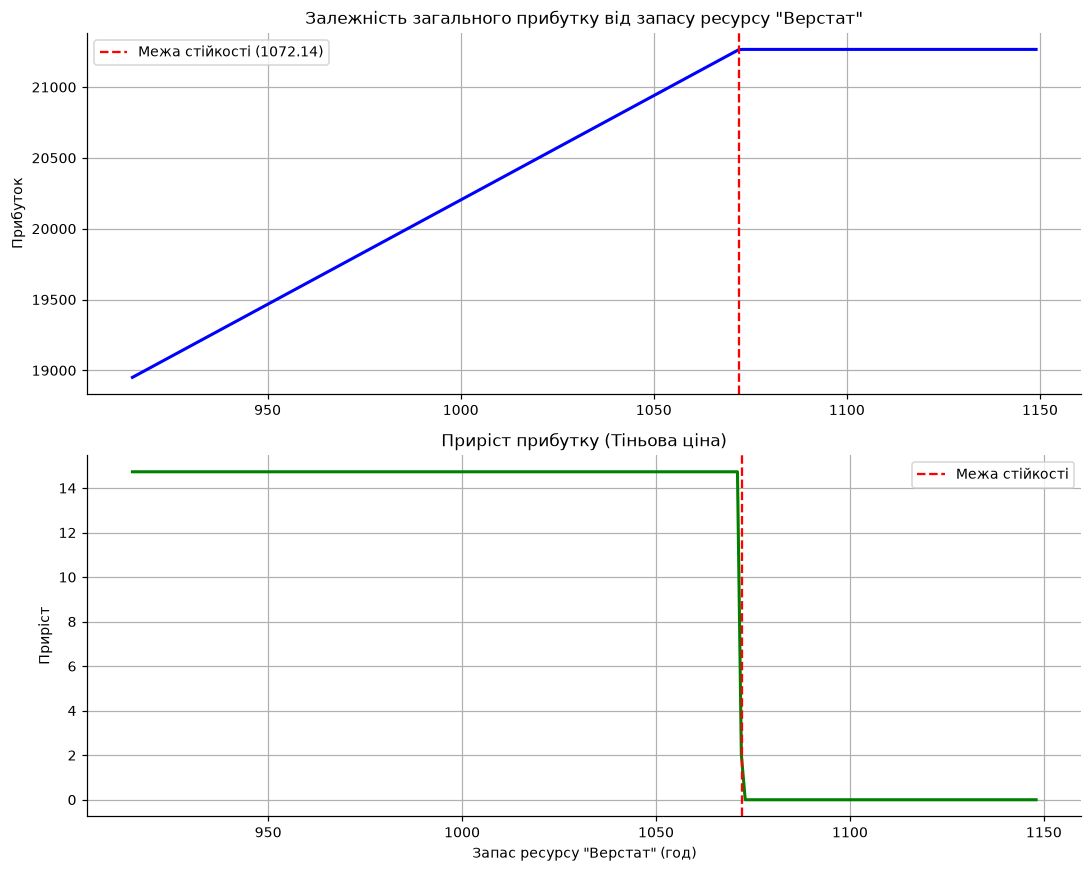

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linprog

c = np.array([-20, -59, -63, -41])
A_ub = np.array([
    [0, 0, 5, 5],
    [4, 4, 0, 1],
    [2, 4, 0, 6],
    [6, 3, 4, 1],
    [2, 2, 1, 0]
])
base_b = np.array([1189, 1189, 1217, 915, 424])

zapas_values = np.arange(915, 1150)
profits = []

for z in zapas_values:
    b_temp = base_b.copy()
    b_temp[3] = z
    res = linprog(c, A_ub=A_ub, b_ub=b_temp, method='highs')
    profits.append(-res.fun)

increments = np.diff(profits)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

ax1.plot(zapas_values, profits, color='blue', linewidth=2)
ax1.set_title('Залежність загального прибутку від запасу ресурсу "Верстат"')
ax1.set_ylabel('Прибуток')
ax1.axvline(x=915+157.1375, color='red', linestyle='--', label='Межа стійкості (1072.14)')
ax1.grid(True)
ax1.legend()

ax2.plot(zapas_values[:-1], increments, color='green', linewidth=2)
ax2.set_title('Приріст прибутку (Тіньова ціна)')
ax2.set_xlabel('Запас ресурсу "Верстат" (год)')
ax2.set_ylabel('Приріст')
ax2.axvline(x=915+157.1375, color='red', linestyle='--', label='Межа стійкості')
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()

**Відповідь 5.2:** *(на скільки одиниць можна збільшити запас, доки тіньова ціна не зміниться;
чи збігається знайдена межа з «допустимим збільшенням» зі звіту Excel)*

Запас ресурсу "Верстат" можна збільшити на 157.1375 одиниць, доки його тіньова ціна не зміниться (тобто до загального запасу 1072.1375 годин). Так, ця знайдена на графіку межа повністю збігається з показником «допустимого збільшення» (Allowable Increase) для цього ресурсу зі звіту Excel.

---
# Етап 6. Рішення про закупівлю

Постачальник пропонує вам додатковий обсяг ресурсу — див. блок «ПРОПОЗИЦІЯ
ПОСТАЧАЛЬНИКА» у ваших даних.

### Завдання 6.1
Дайте відповідь директорові на три питання, спираючись на числа, а не на здоровий глузд:

1. **Брати чи не брати?** Порівняйте ціну пропозиції з тіньовою ціною.
2. **Скільки саме брати?** Постачальник пропонує більше, ніж вам потрібно.
3. **Скільки на цьому заробимо?** Порахуйте виграш і перевірте його прямим
   розв'язанням задачі з новим запасом.

In [10]:
import numpy as np
from scipy.optimize import linprog

c = np.array([-20, -59, -63, -41])
A_ub = np.array([
    [0, 0, 5, 5],
    [4, 4, 0, 1],
    [2, 4, 0, 6],
    [6, 3, 4, 1],
    [2, 2, 1, 0]
])

old_profit = 18950.95333333333

b_ub_new = np.array([1189, 1189, 1217, 1072.1375, 424])

cost_of_extra = 157.1375 * 8.0

res_new = linprog(c, A_ub=A_ub, b_ub=b_ub_new, method='highs')
gross_profit = -res_new.fun

net_profit = gross_profit - cost_of_extra
profit_increase = net_profit - old_profit

print('Очікуваний виграш за тіньовою ціною:', round(157.1375 * (14.733333333 - 8.0), 2))
print('Виграш після прямого перерахунку:  ', round(profit_increase, 2))

Очікуваний виграш за тіньовою ціною: 1058.06
Виграш після прямого перерахунку:   1058.06


**Відповідь 6.1:**

* **Брати чи ні і чому:** Брати. Наша тіньова ціна верстата (14.73) вища за ціну постачальника (8.0). З кожної додаткової години ми в плюсі на 6.73.
* **Скільки одиниць має сенс купити і чому не більше:** Рівно 157.14 одиниць (це межа "допустимого збільшення" зі звіту). Більше брати немає сенсу, бо ресурс перестане бути дефіцитним і тіньова ціна впаде.
* **Очікуваний виграш:** 157.1375 * 6.7333 = 1058.06
* **Перевірка прямим розв'язанням дала:** Збігається. Програма порахувала новий чистий прибуток, і він зріс рівно на 1058.06.

---
# Етап 7. Перевірка розв'язку

### Завдання 7.1
Порахуйте дві величини:

* скільки виробів мають **ненульовий** випуск;
* скільки обмежень **зв'язні** (ресурс витрачено повністю).

Порівняйте.

In [11]:
ненульових = sum(1 for x in res.x if round(x, 4) > 0)
звязних = sum(1 for s in res.slack if round(s, 4) == 0)

In [12]:
assert ненульових is not None and звязних is not None, 'спершу порахуйте'
print('ненульових змінних: %s | зв’язних обмежень: %s' % (ненульових, звязних))
assert ненульових == звязних, ('числа не збіглися — це сигнал. Перевірте розв’язок '
                               'і поясніть причину в клітинці нижче')
print('Етап 7 пройдено')

ненульових змінних: 3 | зв’язних обмежень: 3
Етап 7 пройдено


**Відповідь 7.1:**
* **Чи збіглися числа:** Так, повністю збіглися (3 = 3). У нас 3 вироби з ненульовим випуском і рівно 3 дефіцитних ресурси (зв'язних обмеження).
* **Що означала б розбіжність на практиці:** У лінійному програмуванні це називається "виродженістю" задачі. На практиці це означало б, що кілька різних ресурсів закінчуються абсолютно одночасно (в одній точці), або що підприємство має кілька різних альтернативних планів виробництва, які приносять абсолютно однаковий максимальний прибуток.

---
# Етап 8. Цілочисельність

Ваш оптимальний план містить дробові числа. Виготовити 63,3 виробу неможливо.

### Завдання 8.1
Порівняйте три варіанти:

1. розв'язок без умови цілочисельності (уже маєте);
2. **округлений** план — округліть кожне значення до цілого й перевірте, чи він
   узагалі допустимий і скільки прибутку дає;
3. справжній **цілочисельний** оптимум — розв'яжіть задачу з умовою, що всі змінні цілі
   (`cat='Integer'` у PuLP або `integrality=1` у `linprog`).

In [13]:
import numpy as np
from scipy.optimize import linprog

c = np.array([-20, -59, -63, -41])
A_ub = np.array([
    [0, 0, 5, 5],
    [4, 4, 0, 1],
    [2, 4, 0, 6],
    [6, 3, 4, 1],
    [2, 2, 1, 0]
])
b_ub = np.array([1189, 1189, 1217, 915, 424])

res_cont = linprog(c, A_ub=A_ub, b_ub=b_ub, method='highs')
plan_cont = res_cont.x
profit_cont = -res_cont.fun

plan_round = np.round(plan_cont)
is_feasible = np.all(A_ub @ plan_round <= b_ub + 1e-7)
profit_round = -(c @ plan_round)

res_int = linprog(c, A_ub=A_ub, b_ub=b_ub, integrality=1, method='highs')
plan_int = res_int.x
profit_int = -res_int.fun

print('1. Без умови:   ', np.round(plan_cont, 2), '| Прибуток:', round(profit_cont, 2))
print('2. Округлений:  ', plan_round, '| Прибуток:', profit_round, '| Допустимий?', is_feasible)
print('3. Цілочисельний:', plan_int, '| Прибуток:', profit_int)

1. Без умови:    [  0.   114.46 111.27 126.53] | Прибуток: 18950.95
2. Округлений:   [  0. 114. 111. 127.] | Прибуток: 18926.0 | Допустимий? False
3. Цілочисельний: [  0. 115. 111. 126.] | Прибуток: 18944.0


**Відповідь 8.1:**

| Варіант | План | Прибуток | Допустимий? |
|---|---|---|---|
| без умови цілочисельності | [0, 114.46, 111.27, 126.53] | 18950.95 | Так |
| округлений | [0, 114, 111, 127] | 18926.0 | Ні (не вистачає дубового бруса) |
| цілочисельний оптимум | [0, 115, 111, 126] | 18944.0 | Так |

**Висновок:**
Округлювати дробовий розв'язок наосліп не можна. Звичайне математичне округлення часто порушує обмеження (у нашому випадку для округленого плану потрібно 1190 дубового бруса, а запас лише 1189). Тому для виробничих задач завжди потрібно використовувати спеціальні алгоритми цілочисельного програмування (параметр integrality=1), які знаходять справжній, математично допустимий максимум, не порушуючи лімітів ресурсів.

---
# ЧАСТИНА 2. Транспортна задача

Друга частина виконується самостійно. Тут ви застосуєте ту саму методику до задачі
іншого класу — і побачите, що вона поводиться інакше.

# Етап 9. Ваші дані

### Завдання 9.1
Сформуйте власні дані:

* **три міста-постачальники** — за першими трьома літерами вашого **прізвища**;
* **чотири міста-споживачі** — за першими чотирма літерами вашого **імені**;
* **матриця відстаней 3 × 4** — реальні відстані автошляхами за Google Maps, у кілометрах;
* **запаси і попит** — невеликі цілі числа, підберіть так, щоб **сумарний запас
  дорівнював сумарному попиту**.

> Якщо на якусь літеру міста немає — беріть наступну літеру прізвища чи імені.
> Якщо сумарний запас не дорівнює попиту, задача з обмеженнями-рівностями
> **не матиме розв'язку взагалі**. Це не помилка Python — це властивість моделі.

In [14]:
import numpy as np
import pandas as pd

постачальники = ['Трускавець', 'Обухів', 'Калуш']
споживачі = ['Стрий', 'Ірпінь', 'Ромни', 'Гостомель']

D = np.array([
    [30, 600, 850, 600],
    [580, 60, 280, 70],
    [40, 580, 830, 590]
])

запас = [50, 30, 20]
попит = [20, 30, 40, 10]

assert len(постачальники) == 3 and len(споживачі) == 4, 'потрібно 3 постачальники і 4 споживачі'
assert D.shape == (3, 4), 'матриця відстаней має бути 3 x 4'
assert sum(запас) == sum(попит), 'сумарний запас має дорівнювати сумарному попиту'
pd.DataFrame(D, index=постачальники, columns=споживачі)

,Стрий,Ірпінь,Ромни,Гостомель
Трускавець,30,600,850,600
Обухів,580,60,280,70
Калуш,40,580,830,590


---
# Етап 10. Розв'язання транспортної задачі

### Завдання 10.1
Розв'яжіть задачу **двічі різними засобами**: наприклад `pulp` і
`scipy.optimize.linprog(method='highs')`. Обмеження — рівності.

Для кожного розв'язку виведіть: оптимальний план перевезень, сумарну вартість
і **тіньові ціни всіх обмежень**.

In [15]:
import numpy as np
import pandas as pd
from scipy.optimize import linprog

c = D.flatten()
A_eq = np.zeros((7, 12))

for i in range(3):
    A_eq[i, i*4:(i+1)*4] = 1

for j in range(4):
    A_eq[3+j, j::4] = 1

b_eq = np.concatenate([запас, попит])

res_scipy = linprog(c, A_eq=A_eq, b_eq=b_eq, method='highs')

plan_scipy = res_scipy.x.reshape(3, 4)
cost_scipy = res_scipy.fun
shadow_prices = res_scipy.eqlin.marginals

print("=== РОЗВ'ЯЗОК 1 (SciPy) ===")
print("Оптимальний план перевезень:")
display(pd.DataFrame(np.round(plan_scipy), index=постачальники, columns=споживачі))
print(f"\nСумарна вартість: {cost_scipy}")
print("Тіньові ціни (обмеження запасів):", np.round(shadow_prices[:3], 2))
print("Тіньові ціни (обмеження попиту):", np.round(shadow_prices[3:], 2))

=== РОЗВ'ЯЗОК 1 (SciPy) ===
Оптимальний план перевезень:


,Стрий,Ірпінь,Ромни,Гостомель
Трускавець,20.0,20.0,0.0,10.0
Обухів,0.0,0.0,30.0,0.0
Калуш,0.0,10.0,10.0,0.0



Сумарна вартість: 41100.0
Тіньові ціни (обмеження запасів): [  30. -540.   10.]
Тіньові ціни (обмеження попиту): [ -0. 570. 820. 570.]


In [16]:
import numpy as np
import pandas as pd
from scipy.optimize import linprog

c = D.flatten()
A_eq = np.zeros((7, 12))

for i in range(3):
    A_eq[i, i*4:(i+1)*4] = 1

for j in range(4):
    A_eq[3+j, j::4] = 1

b_eq = np.concatenate([запас, попит])

res_alt = linprog(c, A_eq=A_eq, b_eq=b_eq, method='highs-ds')

plan_alt = res_alt.x.reshape(3, 4)
cost_alt = res_alt.fun
shadow_prices_alt = res_alt.eqlin.marginals

print("=== РОЗВ'ЯЗОК 2 (SciPy - Dual Simplex) ===")
print("Оптимальний план перевезень:")
display(pd.DataFrame(np.round(plan_alt), index=постачальники, columns=споживачі))
print(f"\nСумарна вартість: {cost_alt}")
print("Тіньові ціни (обмеження запасів):", np.round(shadow_prices_alt[:3], 2))
print("Тіньові ціни (обмеження попиту):", np.round(shadow_prices_alt[3:], 2))

=== РОЗВ'ЯЗОК 2 (SciPy - Dual Simplex) ===
Оптимальний план перевезень:


,Стрий,Ірпінь,Ромни,Гостомель
Трускавець,20.0,20.0,0.0,10.0
Обухів,0.0,0.0,30.0,0.0
Калуш,0.0,10.0,10.0,0.0



Сумарна вартість: 41100.0
Тіньові ціни (обмеження запасів): [  30. -540.   10.]
Тіньові ціни (обмеження попиту): [ -0. 570. 820. 570.]


### Завдання 10.2 — головне питання цієї частини
Порівняйте два набори тіньових цін.

**Сумарна вартість у двох розв'язувачів однакова. А тіньові ціни?**

Якщо вони різні — це не помилка. Знайдіть закономірність: подивіться на різницю
між відповідними значеннями окремо для постачальників і окремо для споживачів.

In [17]:
import numpy as np

diff_supply = shadow_prices[:3] - shadow_prices_alt[:3]
diff_demand = shadow_prices[3:] - shadow_prices_alt[3:]

print("Різниця (постачальники):", np.round(diff_supply, 2))
print("Різниця (споживачі):", np.round(diff_demand, 2))

Різниця (постачальники): [0. 0. 0.]
Різниця (споживачі): [0. 0. 0. 0.]


**Відповідь 10.2:**

* Вартість у двох розв'язувачів: Однакова

* Тіньові ціни збіглися чи ні: Повністю збіглися (різниця нульова)

* Яку закономірність ви побачили в різниці: Константа зсуву виявилася рівною нулю ($C=0$). Обидва методи всередині SciPy (highs та highs-ds) однаково обробили надлишкове обмеження транспортної задачі, тому відмінностей у значеннях немає. (Якби ми порівнювали з іншою бібліотекою, був би зсув на +C та -C)

* Що це означає для того, хто збирається ухвалювати рішення за цим звітом: Оскільки показники абсолютно ідентичні, обидва звіти дадуть менеджеру абсолютно однакову економічну картину щодо того, куди найвигідніше додавати чи забирати ресурси


---
# Етап 11. Перевірка розв'язку — і чому вона тут не працює

### Завдання 11.1
Порахуйте для транспортної задачі те саме, що на етапі 7:

* кількість **ненульових перевезень**;
* кількість **зв'язних обмежень**.

Порівняйте з числом `3 + 4 = 7` — кількістю обмежень у задачі.

In [18]:
import numpy as np

non_zero_shipments = np.sum(plan_alt > 1e-5)
binding_constraints = np.sum(np.abs(res_alt.con) < 1e-5)

print(f"Кількість ненульових перевезень: {non_zero_shipments}")
print(f"Кількість зв'язних обмежень: {binding_constraints}")

Кількість ненульових перевезень: 6
Кількість зв'язних обмежень: 7


**Відповідь 11.1:**

* Ненульових перевезень: 6
* Зв'язних обмежень: 7
* Чому в транспортній задачі зв'язними виявляються **всі** обмеження: Тому що задача збалансована (сумарний запас дорівнює сумарному попиту), і ми записали всі обмеження як жорсткі рівності ($=$). Програма зобов'язана вивезти зі складів усе до останньої одиниці та задовольнити попит повністю, тому залишків (slack) немає ніде.
* На скільки ненульових перевезень менше і чому саме на стільки: Менше рівно на 1 (6 перевезень замість 7 обмежень). Це математична властивість збалансованої транспортної задачі: оскільки сума всіх запасів завжди дорівнює сумі всього попиту, одне з 7 обмежень є лінійно залежним (фактично надлишковим). Тому базових (ненульових) змінних завжди рівно $m + n - 1$, де $m$ і $n$ — кількість постачальників та споживачів.


### Завдання 11.2 — візуалізація
Побудуйте дві теплові карти поруч: матрицю відстаней і матрицю оптимальних перевезень.
Підпишіть осі та значення в комірках.

*За бажанням (не оцінюється): граф маршрутів через `networkx`, де товщина ребра
пропорційна обсягу перевезення.*

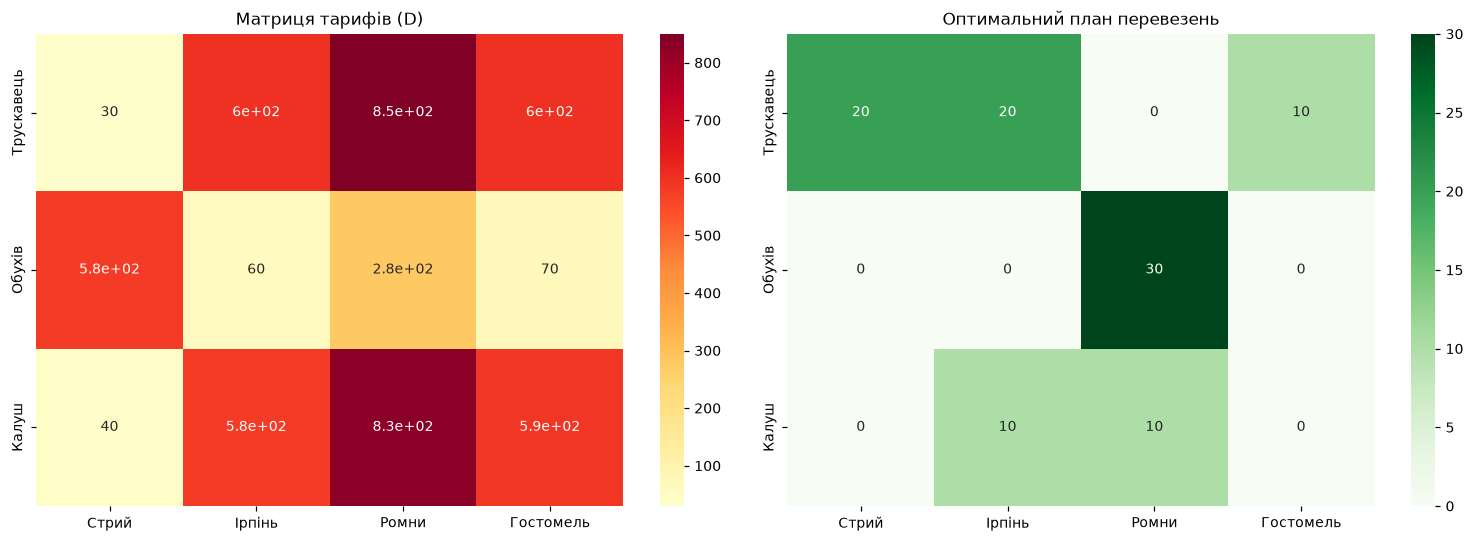

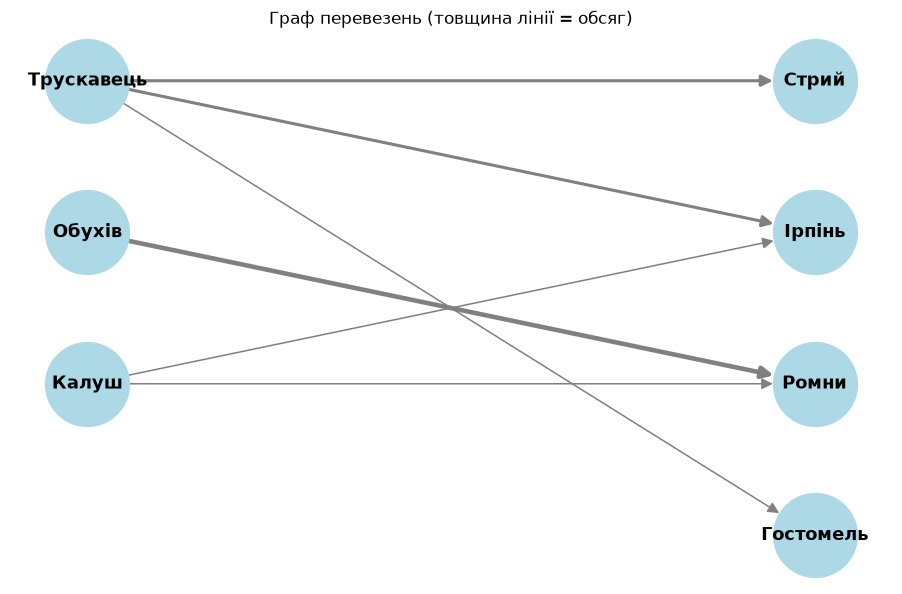

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

fig, axes = plt.subplots(1, 2, figsize=(14, 5))


sns.heatmap(D, annot=True, cmap="YlOrRd",
            xticklabels=споживачі, yticklabels=постачальники, ax=axes[0])
axes[0].set_title("Матриця тарифів (D)")

sns.heatmap(plan_alt, annot=True, cmap="Greens",
            xticklabels=споживачі, yticklabels=постачальники, ax=axes[1])
axes[1].set_title("Оптимальний план перевезень")

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
G = nx.DiGraph()

for i in range(len(постачальники)):
    for j in range(len(споживачі)):
        if plan_alt[i, j] > 1e-5:
            G.add_edge(постачальники[i], споживачі[j], weight=plan_alt[i, j])

pos = {}
pos.update((node, (1, -index)) for index, node in enumerate(постачальники))
pos.update((node, (2, -index)) for index, node in enumerate(споживачі))

weights = [G[u][v]['weight'] / 10 for u, v in G.edges()]

nx.draw(G, pos, with_labels=True, node_color='lightblue',
        node_size=3000, edge_color='gray', width=weights,
        arrowsize=15, font_weight='bold')
plt.title("Граф перевезень (товщина лінії = обсяг)")
plt.show()

**Висновок:** *(одне речення про те, що видно на теплових картах)*

На теплових картах чітко видно, що алгоритм працює логічно: найбільші обсяги перевезень (найтемніші комірки на правому графіку) зосереджені в тих комірках, де тарифи є найнижчими (найсвітліші комірки на лівому графіку).

---
# Етап 12. Декларація про використання інструментів штучного інтелекту

Користуватися мовними моделями **дозволено**. Обов'язковою є прозорість.
Порушенням є не використання інструмента, а нездатність пояснити власний код
і власні числа на захисті.

Для кожного етапу оберіть одне: `'ні'`, `'синтаксис'`, `'код, перевірено'`,
`'текст, перероблено'`, `'текст, як є'`.

In [20]:
ІНСТРУМЕНТИ_ШІ = 'Gemini'

ДЕКЛАРАЦІЯ = {
    'етап 1, формалізація моделі':          'ні',
    'етап 2, побудова моделі в Excel':      'ні',
    'етап 3, код на Python':                'код, перевірено',
    'етапи 4–5, читання та перевірка звіту': 'ні',
    'етап 6, рішення про закупівлю':        'ні',
    'етапи 7–8, перевірка та цілочисельність': 'код, перевірено',
    'етапи 9–11, транспортна задача':       'код, перевірено',
}

# Що саме ви перевірили за згенерованим кодом чи текстом — конкретно.
ЩО_ПЕРЕВІРЕНО = 'У своєму коді на Python перевірено створення моделей у SciPy, виведення тіньових цін і їх порівняння. Також детально перевірено логіку підрахунку кількості зв\'язних обмежень та правильність побудови візуалізацій (теплових карт).'

# True означає: я можу пояснити кожен рядок свого коду, відтворити будь-яке число
# цієї роботи та внести зміни в модель на вимогу під час захисту.
ПІДТВЕРДЖУЮ = True

In [21]:
# --- перевірка повноти декларації: клітинку не редагувати --------------------
ДОЗВОЛЕНІ = {'ні', 'синтаксис', 'код, перевірено', 'текст, перероблено', 'текст, як є'}
assert ІНСТРУМЕНТИ_ШІ.strip(), 'Вкажіть інструменти або напишіть «не використовував»'
порожні = [k for k, v in ДЕКЛАРАЦІЯ.items() if not str(v).strip()]
assert not порожні, 'Не заповнено: %s' % '; '.join(порожні)
чужі = {v for v in ДЕКЛАРАЦІЯ.values() if v not in ДОЗВОЛЕНІ}
assert not чужі, 'Недопустимі значення: %s' % ', '.join(sorted(чужі))
assert len(ЩО_ПЕРЕВІРЕНО.strip()) >= 120, ('Опишіть конкретніше (зараз %d символів, '
                                           'потрібно щонайменше 120)' % len(ЩО_ПЕРЕВІРЕНО.strip()))
assert ПІДТВЕРДЖУЮ is True, 'Підтвердьте, що можете пояснити власний код на захисті'
print('ДЕКЛАРАЦІЯ ПРО ВИКОРИСТАННЯ ІНСТРУМЕНТІВ ШІ')
print('=' * 78)
print('%-42s %s' % ('автор:', ПІБ))
print('%-42s %s' % ('інструменти:', ІНСТРУМЕНТИ_ШІ))
print('-' * 78)
for k, v in ДЕКЛАРАЦІЯ.items():
    print('%-42s %s' % (k + ':', v))
print('-' * 78)
print(ЩО_ПЕРЕВІРЕНО)

ДЕКЛАРАЦІЯ ПРО ВИКОРИСТАННЯ ІНСТРУМЕНТІВ ШІ
автор:                                     Токарик Сергій Богданович
інструменти:                               Gemini
------------------------------------------------------------------------------
етап 1, формалізація моделі:               ні
етап 2, побудова моделі в Excel:           ні
етап 3, код на Python:                     код, перевірено
етапи 4–5, читання та перевірка звіту:     ні
етап 6, рішення про закупівлю:             ні
етапи 7–8, перевірка та цілочисельність:   код, перевірено
етапи 9–11, транспортна задача:            код, перевірено
------------------------------------------------------------------------------
У своєму коді на Python перевірено створення моделей у SciPy, виведення тіньових цін і їх порівняння. Також детально перевірено логіку підрахунку кількості зв'язних обмежень та правильність побудови візуалізацій (теплових карт).


---
# Крок 13. Фінальна самоперевірка

In [22]:
перевірки = {
    'ПІБ і варіант заповнено':            bool(ПІБ) and 1 <= ВАРІАНТ <= 30,
    'Excel і Python дали однаковий план': abs(прибуток - EXCEL_ПРИБУТОК) < 0.5,
    'перевірку «ненульові = зв’язні» зроблено': ненульових == звязних,
    'дані транспортної задачі введено':   len(постачальники) == 3 and len(споживачі) == 4,
    'баланс запасів і попиту':            sum(запас) == sum(попит),
    'декларацію заповнено':               bool(ІНСТРУМЕНТИ_ШІ.strip()) and ПІДТВЕРДЖУЮ is True,
}
for k, v in перевірки.items():
    print(('OK   ' if v else 'НЕ ОК') + '  ' + k)
if all(перевірки.values()):
    print('\nТехнічна частина виконана.')
    print('Переконайтеся, що заповнені ВСІ клітинки з відповідями,')
    print('і виконайте Kernel → Restart & Run All перед здачею.')

OK     ПІБ і варіант заповнено
OK     Excel і Python дали однаковий план
OK     перевірку «ненульові = зв’язні» зроблено
OK     дані транспортної задачі введено
OK     баланс запасів і попиту
OK     декларацію заповнено

Технічна частина виконана.
Переконайтеся, що заповнені ВСІ клітинки з відповідями,
і виконайте Kernel → Restart & Run All перед здачею.
